In [1]:
import PIL.Image as image
import matplotlib.pyplot as plt
import numpy as np

Read a grayscale imgae:

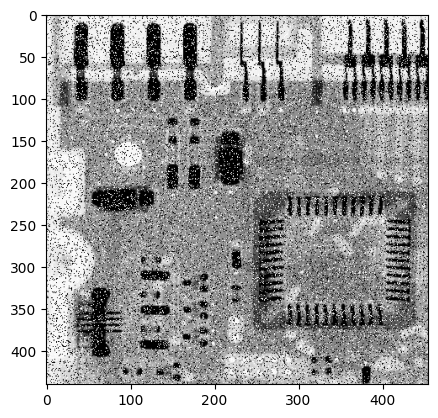

In [2]:
img = image.open('images/pcb.tif').convert('L')
img_array = np.array(img)
plt.imshow(img_array, cmap="gray")
plt.show()
H,W = img_array.shape

Kernel:

In [3]:
filter = np.array([
    [1/9, 1/9, 1/9],
    [1/9, 1/9, 1/9],
    [1/9, 1/9, 1/9],
])


Edge padding / replicate padding:
[
  mode='edge' for replicate padding
  mode='constant' for fixed pading, use constant_values param
  mode='wrap' for using the opposite edge values
]

In [ ]:
padded_img = np.pad(img, pad_width=1, mode='edge')

Averaging Filter:

In [5]:
output1 = np.zeros_like(img)

for i in range(H):
    for j in range(W):
        region = padded_img[i:i+3, j:j+3]
        output1[i,j]=np.sum(region * filter)

Median Filter:

In [6]:
output2 = np.zeros_like(img)

for i in range(H):
    for j in range(W):
        region = padded_img[i:i+3, j:j+3]
        output2[i,j]=np.median(region)

Displaying original, averaging filtered, Median filtered images:

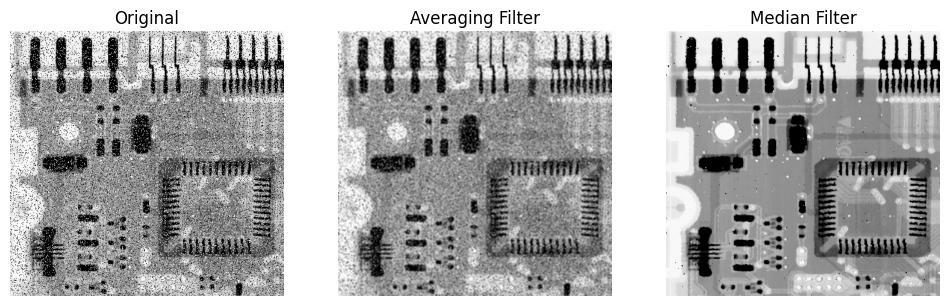

In [ ]:
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(img,cmap='gray')
plt.title("Original")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(output1,cmap='gray')
plt.title("Averaging Filter")
plt.axis("off")


plt.subplot(1,3,3)
plt.imshow(output2,cmap='gray')
plt.title("Median Filter")
plt.axis("off")

plt.show()
